# Project Data Processing / Cleaning Outline
This sections should be described in full in a brief paragraph in our report


1. data cleaning: the basic dtypes, null values handling, outlier using variance detection and removal, standardizing data attributes when needed.
2. data processing

In [27]:
import pandas as pd
import seaborn as sns
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('BTS_OnTimePerformanceData_202409_202502.csv')
df.head()

# crs is scheduled dept time
# dep is actual time of dept

,op_unique_carrier,fl_date,crs_dep_time,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,...,origin_airport_id,origin,origin_city_name,origin_state_abr,origin_state_nm,dest_airport_id,dest,dest_city_name,dest_state_abr,dest_state_nm
0,9E,9/1/2024 12:00:00 AM,510,500,13.0,513,603,11.0,639,614,...,10785,BTV,"Burlington, VT",VT,Vermont,12478,JFK,"New York, NY",NY,New York
1,9E,9/1/2024 12:00:00 AM,530,530,13.0,543,631,7.0,654,638,...,14576,ROC,"Rochester, NY",NY,New York,12478,JFK,"New York, NY",NY,New York
2,9E,9/1/2024 12:00:00 AM,536,528,25.0,553,639,7.0,700,646,...,15096,SYR,"Syracuse, NY",NY,New York,12478,JFK,"New York, NY",NY,New York
3,9E,9/1/2024 12:00:00 AM,539,531,25.0,556,654,6.0,709,700,...,15096,SYR,"Syracuse, NY",NY,New York,11433,DTW,"Detroit, MI",MI,Michigan
4,9E,9/1/2024 12:00:00 AM,540,526,38.0,604,648,9.0,700,657,...,12397,ITH,"Ithaca/Cortland, NY",NY,New York,12478,JFK,"New York, NY",NY,New York


In [3]:
df = df[['op_unique_carrier', 'crs_dep_time', 'dep_time', 
    'year', 'quarter', 'month', 'day_of_month', 'day_of_week',
    'op_carrier_airline_id', 'op_carrier', 'fl_date',
    'origin_airport_id', 'origin', 'origin_city_name', 'origin_state_abr',
    'dest', 'dest_city_name', 'dest_state_abr', 'dest_state_nm']]

# Convert dates and clean types
df['fl_date'] = pd.to_datetime(df['fl_date'])

# Create a delay target variable (in minutes)
df['departure_delay'] = df['dep_time'] - df['crs_dep_time']

# Normalize wrap-around times (e.g., flights scheduled for 23:50, arriving 00:10)
df['departure_delay'] = df['departure_delay'].apply(lambda x: x if -600 < x < 1000 else np.nan)

# Drop rows with missing values in critical fields
df = df.dropna(subset=['departure_delay', 'origin', 'dest'])

df['citypair'] = df.apply(lambda row: '-'.join(sorted([row['origin'], row['dest']])), axis=1)


/var/folders/dx/fkkt7g89031g4ydyg21rm79r0000gq/T/ipykernel_38544/131825581.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fl_date'] = pd.to_datetime(df['fl_date'])


In [23]:
filtered_df = df[df['departure_delay'] > 0]

In [33]:
# Group by citypair and aggregate
routes_summary = filtered_df.groupby('citypair')['departure_delay'].agg(
    num_occurrences='count',
    avg_delay='mean',
    var_delay='var'  # Use 'std' if you want standard deviation
).reset_index()

routes_summary

,citypair,num_occurrences,avg_delay,var_delay
0,ABE-ATL,154,77.214286,18688.352474
1,ABE-BNA,14,30.642857,1155.170330
2,ABE-CLT,358,77.418994,14904.148882
3,ABE-DEN,8,142.250000,66848.500000
4,ABE-FLL,33,131.939394,24647.683712
...,...,...,...,...
3140,STL-VPS,11,11.181818,360.363636
3141,TPA-TTN,42,77.833333,13657.849593
3142,TPA-TYS,2,15.000000,0.000000
3143,TYS-VPS,11,75.818182,21529.763636


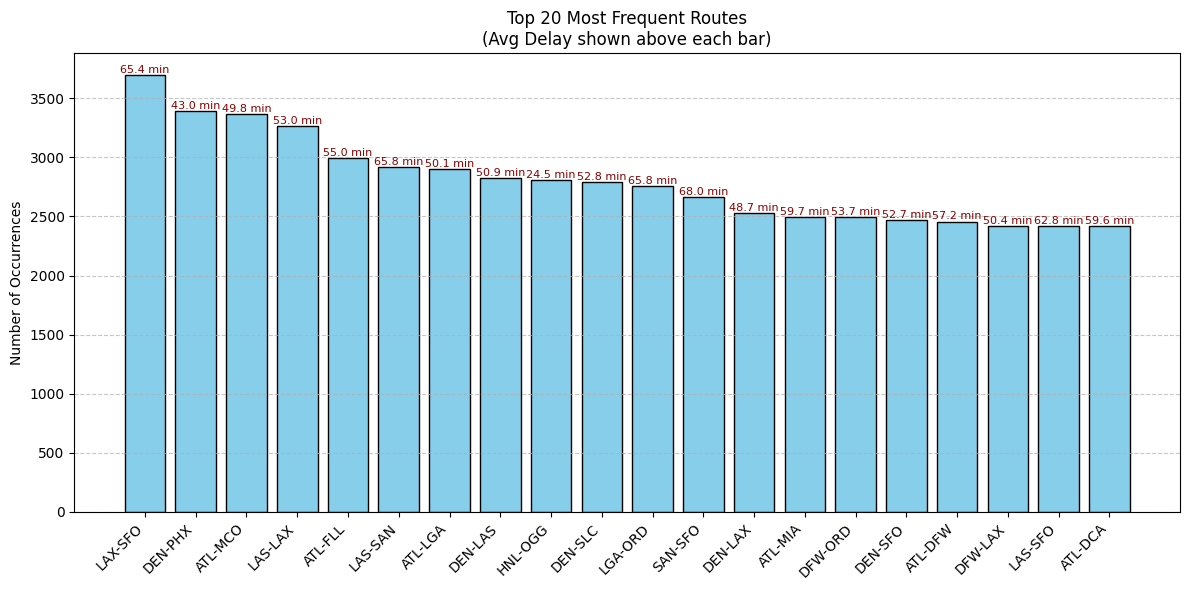

In [36]:
# Sort and select top 20 routes by frequency
top_routes = routes_summary.sort_values(by='num_occurrences', ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(top_routes['citypair'], top_routes['num_occurrences'], color='skyblue', edgecolor='black')

# Add average delay as text label on top of each bar
for bar, avg_delay in zip(bars, top_routes['avg_delay']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{avg_delay:.1f} min", 
             ha='center', va='bottom', fontsize=8, color='darkred')

# Labels and title
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Occurrences')
plt.title('Top 20 Most Frequent Routes\n(Avg Delay shown above each bar)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

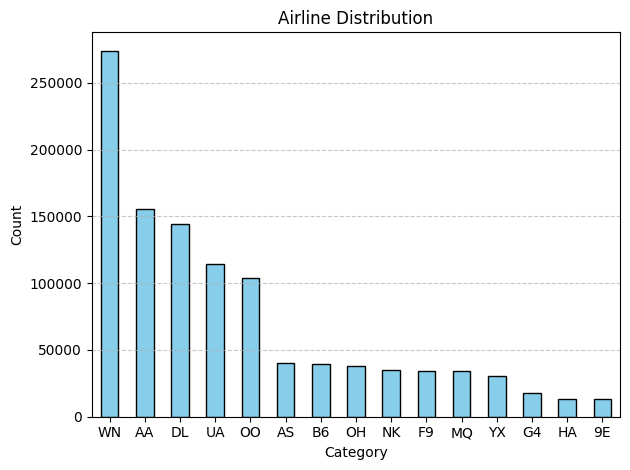

In [30]:
# Count occurrences of each category
category_counts = filtered_df['op_unique_carrier'].value_counts()

# Plot bar chart
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Airline Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

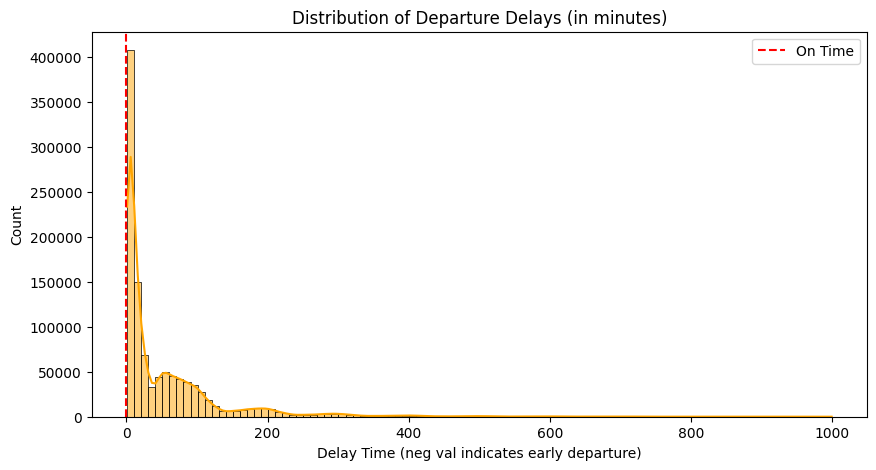

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(filtered_df['departure_delay'], bins=100, kde=True, color='orange')
plt.title("Distribution of Departure Delays (in minutes)")
plt.xlabel("Delay Time (neg val indicates early departure)")
plt.ylabel("Count")
plt.axvline(x=0, color='red', linestyle='--', label='On Time')
plt.legend()
plt.show()


In [6]:
# Convert to date to group daily
df['fl_date'] = pd.to_datetime(df['fl_date'])

# All airports (origin and dest combined)
origin_stats = df.groupby(['origin', 'origin_city_name', 'fl_date']).agg(
    flights=('citypair', 'count'),
    delayed=('departure_delay', lambda x: (x > 0).sum())
).reset_index()

# Average flights per day
daily_flights = origin_stats.groupby(['origin', 'origin_city_name']).agg(
    avg_daily_flights=('flights', 'mean'),
    avg_daily_delayed=('delayed', 'mean')
).reset_index()

# Compute percent of flights delayed
daily_flights['percent_delayed'] = 100 * daily_flights['avg_daily_delayed'] / daily_flights['avg_daily_flights']

# Unique airline counts
airlines_per_airport = df.groupby('origin')['op_unique_carrier'].agg(
    unique_airlines=lambda x: list(set(x)),
    num_unique_airlines=lambda x: x.nunique()
).reset_index()

# Delay statistics
delay_stats = df.groupby('origin')['departure_delay'].agg(
    mean_dep_delay='mean',
    std_dep_delay='std'
).reset_index()

# Merge all airport-level info
airports_node_table = daily_flights.merge(airlines_per_airport, on='origin')
airports_node_table = airports_node_table.merge(delay_stats, on='origin')

# Rename and reorder columns
airports_node_table = airports_node_table.rename(columns={
    'origin': 'airport_code',
    'origin_city_name': 'city_name'
})[[
    'airport_code', 'city_name', 'avg_daily_flights', 'percent_delayed',
    'num_unique_airlines', 'unique_airlines', 'mean_dep_delay', 'std_dep_delay'
]].sort_values(by='avg_daily_flights', ascending=False)


In [22]:
airports_node_table.to_csv("airports.csv")

In [37]:
airports_node_table

,airport_code,city_name,avg_daily_flights,percent_delayed,num_unique_airlines,unique_airlines,mean_dep_delay,std_dep_delay
20,ATL,"Atlanta, GA",875.707182,33.502205,13,"[OO, UA, 9E, AA, WN, NK, YX, DL, F9, OH, B6, M...",11.095033,52.473641
90,DEN,"Denver, CO",826.337017,38.870205,10,"[OO, UA, AA, WN, DL, F9, G4, B6, MQ, AS]",11.841161,54.011155
91,DFW,"Dallas/Fort Worth, TX",823.325967,37.007288,12,"[OO, UA, 9E, AA, YX, NK, DL, F9, OH, B6, MQ, AS]",16.483439,63.404770
238,ORD,"Chicago, IL",746.911602,34.298881,12,"[OO, UA, 9E, AA, WN, NK, YX, DL, F9, B6, MQ, AS]",12.450400,58.942702
70,CLT,"Charlotte, NC",572.060773,36.747052,11,"[UA, 9E, AA, WN, NK, YX, DL, F9, OH, B6, MQ]",13.555470,56.395242
...,...,...,...,...,...,...,...,...
9,ADK,"Adak Island, AK",1.000000,29.787234,1,[AS],-6.000000,39.851900
308,SMX,"Santa Maria, CA",1.000000,54.000000,1,[G4],40.400000,127.132744
13,AKN,"King Salmon, AK",1.000000,23.333333,1,[AS],-31.500000,41.502597
49,BRW,"Barrow, AK",1.000000,54.385965,1,[AS],8.777778,44.596198


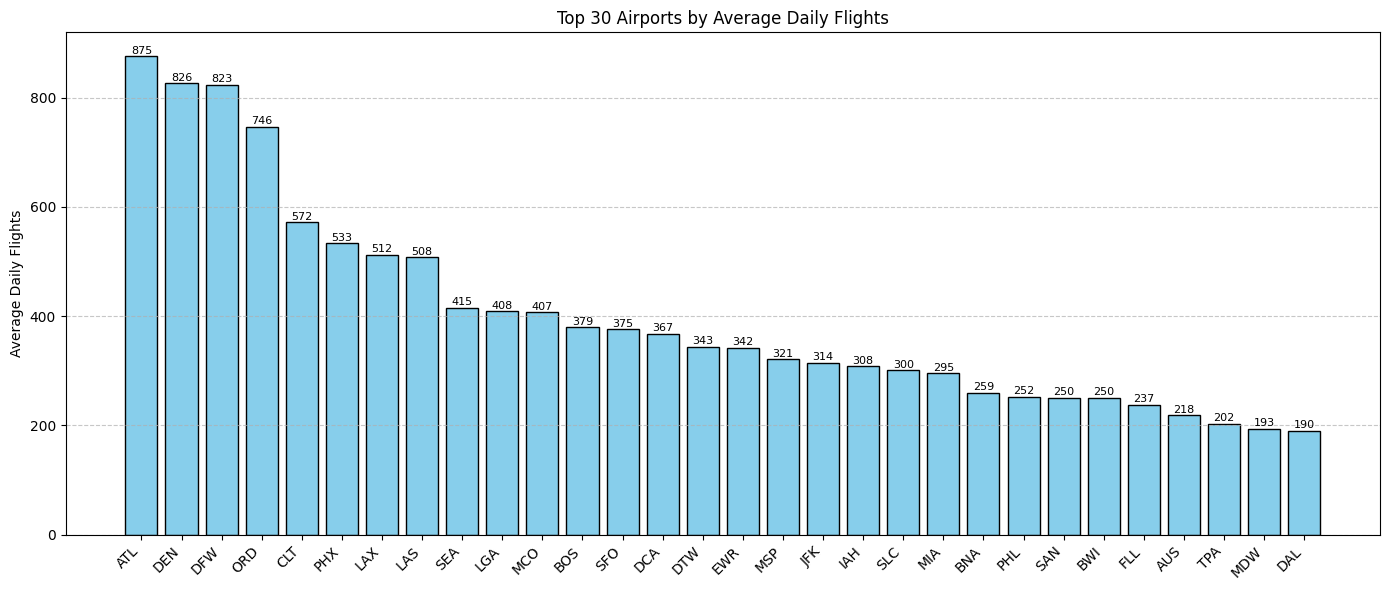

In [39]:
# airport nodes visuals

import matplotlib.pyplot as plt


# Sort and select top 30 airports
top_airports = airports_node_table.sort_values(by='avg_daily_flights', ascending=False).head(30)

# Plot
plt.figure(figsize=(14, 6))
bars = plt.bar(top_airports['airport_code'], top_airports['avg_daily_flights'], color='skyblue', edgecolor='black')

# Add labels to each bar (optional: showing flight counts)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{int(yval)}', ha='center', va='bottom', fontsize=8)

# Formatting
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Daily Flights')
plt.title('Top 30 Airports by Average Daily Flights')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

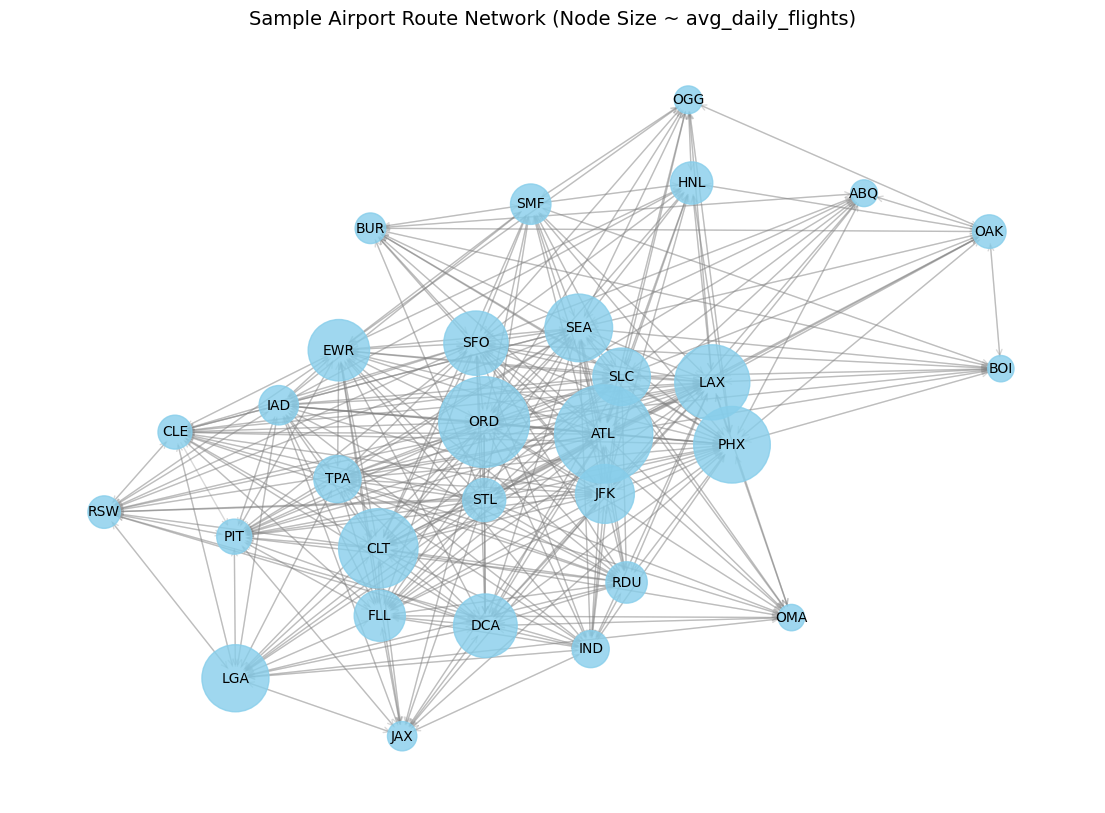

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# --- Step 1: Sample 30 airports based on size ---
sample_airports = airports_node_table.sort_values(by='avg_daily_flights', ascending=False).head(60)
sample_airports = sample_airports.sample(30, random_state=42)  # Add randomness while keeping bigger airports

airport_list = sample_airports['airport_code'].tolist()

# --- Step 2: Filter routes between these airports ---
route_sample = df[df['origin'].isin(airport_list) & df['dest'].isin(airport_list)]

# Build the graph
G = nx.DiGraph()
for _, row in sample_airports.iterrows():
    G.add_node(row['airport_code'], size=row['avg_daily_flights'])

for _, row in route_sample.iterrows():
    G.add_edge(row['origin'], row['dest'])

# --- Step 3: Set up node sizes and labels ---
sizes = [G.nodes[n]['size'] for n in G.nodes()]
scaled_sizes = [s / max(sizes) * 5000 for s in sizes]  # Scale for plotting

labels = {node: node for node in G.nodes()}

# --- Step 4: Draw the network ---
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=scaled_sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=10, edge_color='gray', alpha=0.3)
nx.draw_networkx_labels(G, pos, labels, font_size=10)

plt.title("Sample Airport Route Network (Node Size ~ avg_daily_flights)", fontsize=14)
plt.axis("off")
plt.show()

im working on a project and i need your help with the code analysis and report


here is my project idea and steps at a high level
Flight delays are a significant challenge for the aviation industry, leading to billions in economic losses annu-
ally and major disruptions to passengers and airline operations. Recently, there have been major disruptions
to flights at Newark Liberty International Airport in New Jersey. From May 2025, Newark Airport reported
an average of about 200 delayed flights and 10 canceled flights each day. This has resulting in a chain reac-
tion of delayed and canceled flights across other US airports, resulting in poor passenger experiences, and
millions in lost revenue and increased expenses. These modern day scheduling and airline delay challenges
highlight the importance of new maachine learning techniques and approaches to help predict delays and
provide more clear insights to passengers and airlines during disruptions.
While machine learning has been applied to delay prediction tasks in recent years, many existing models rely
on limited sets of features, such as airline, departure times, and origin-destination pairs. These approaches
often ignore the broader operational and spatial-temporal context in which flights operate. In this project, we
aim to build a more comprehensive and innovative delay prediction model that accounts for these overlooked
dimensions, using a combination of feature engineering, unsupervised learning, and predictive modeling.
2 Problem Statement
The core objective of our project is to predict the arrival delay, in minutes, for U.S. domestic flights. We
extend beyond traditional variables by incorporating new features such as time-of-day effects, day-of-week
patterns, and airport typologies derived through clustering methods. Our hypothesis is that modeling
the structure of airport behavior—e.g., how congested, efficient, or delay-prone an airport is—along with
historical route-level trends, can significantly improve the accuracy and reliability of delay predictions. Prior
research has shown that delay outcomes are not only affected by direct factors like scheduled time and
weather, but also by systemic influences across the air traffic network. Therefore, we introduce structural
context through latent airport clusters and temporal cycles to better capture these dynamics




my dataset looks like this: these are the columns and dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3362286 entries, 0 to 3362285
Data columns (total 29 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   op_unique_carrier      object 
 1   fl_date                object 
 2   crs_dep_time           int64  
 3   dep_time               int64  
 4   taxi_out               float64
 5   wheels_off             int64  
 6   wheels_on              int64  
 7   taxi_in                float64
 8   crs_arr_time           int64  
 9   arr_time               int64  
 10  year                   int64  
 11  quarter                int64  
 12  month                  int64  
 13  day_of_month           int64  
 14  day_of_week            int64  
 15  op_carrier_airline_id  int64  
 16  op_carrier             object 
 17  tail_num               object 
 18  op_carrier_fl_num      int64  
 19  origin_airport_id      int64  
 20  origin                 object 
 21  origin_city_name       object 
 22  origin_state_abr       object 
 23  origin_state_nm        object 
 24  dest_airport_id        int64  
 25  dest                   object 
 26  dest_city_name         object 
 27  dest_state_abr         object 
 28  dest_state_nm          object 
dtypes: float64(2), int64(15), object(12)
memory usage: 743.9+ MB


here is a sample dataset row:
op_unique_carrier                          9E
fl_date                  9/1/2024 12:00:00 AM
crs_dep_time                              510
dep_time                                  500
taxi_out                                 13.0
wheels_off                                513
wheels_on                                 603
taxi_in                                  11.0
crs_arr_time                              639
arr_time                                  614
year                                     2024
quarter                                     3
month                                       9
day_of_month                                1
day_of_week                                 7
op_carrier_airline_id                   20363
op_carrier                                 9E
tail_num                               N691CA
op_carrier_fl_num                        5176
origin_airport_id                       10785
origin                                    BTV
origin_city_name               Burlington, VT
origin_state_abr                           VT
origin_state_nm                       Vermont
dest_airport_id                         12478
dest                                      JFK
dest_city_name                   New York, NY
dest_state_abr                             NY
dest_state_nm                        New York
Name: 0, dtype: object



i want to you to step by step help me with the methodology section. for each of the following sections, write code for the various steps needed, visualiztations highlighting metrics etc that would be useful to add to report, and brief paragraphs describing the steps and analysis for each section

section 1: data processng 
section 2: Exploratory analysis: eda on unique routes, popular cities, network graph visualizations of samples etc be creative
section 3: feature engineering: creating new variables based on current variables to help predict delay times